<a href="https://colab.research.google.com/github/Feng-Luan/Titanic-Survival-Prediction/blob/main/titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction

## Logistic Regression and Random Forest Comparison

This project builds and compares machine learning models to predict passenger survival on the Titanic dataset. The goal is to develop a complete classification pipeline and interpret key factors influencing survival.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

## 2. Load Data

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Exploration

We explore the dataset structure and identify missing values.

In [3]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 4. Data Preprocessing

We clean the data by removing irrelevant columns, handling missing values, and encoding categorical variables.

In [4]:
# Drop unnecessary columns
df=df.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"])

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical variables
df=pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first= True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## 5. Define Features and Target

In [5]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

## 6. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 7. Logistic Regression Model

We first build a baseline model using logistic regression.

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8100558659217877
Confusion Matrix:
 [[90 15]
 [19 55]]
ROC-AUC: 0.8826254826254826


## 8. Random Forest Model

We use a random forest model to capture nonlinear relationships and improve performance.

In [8]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.8212290502793296
Confusion Matrix:
 [[91 14]
 [18 56]]
ROC-AUC: 0.8868725868725867


## 9. Model Comparison

Random Forest outperformed Logistic Regression in both accuracy and ROC-AUC, indicating the presence of nonlinear relationships in the data.

## 10. Feature Importance

We analyze feature importance from the Random Forest model to understand which variables contribute most to predictions.

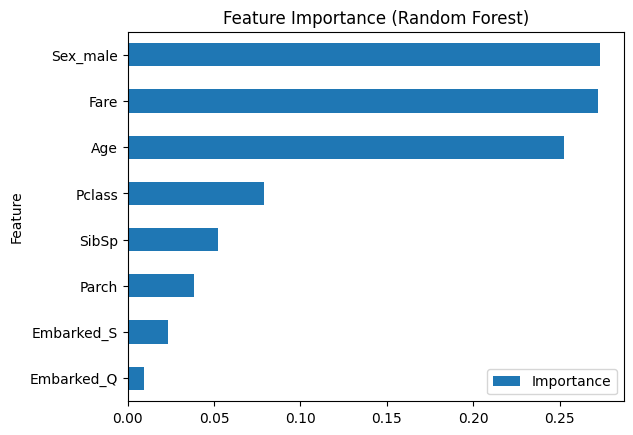

In [9]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importance", ascending=False)

importances.set_index("Feature").head(10).plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

## 11. Conclusion

In this project, we built and compared logistic regression and random forest models for survival prediction.

The random forest model achieved better performance, suggesting that nonlinear relationships exist in the data.

Feature importance analysis showed that gender, fare, and age were the most important predictors of survival, which aligns with real-world patterns.

This project demonstrates a complete machine learning workflow, including data preprocessing, model building, evaluation, and interpretation.